In [4]:
import os
os.makedirs('notebooks/eda_plots', exist_ok=True)
print("Folder created!")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')
load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

def get_engine():
    url = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(url)
    return engine

engine = get_engine()
query = "SELECT * FROM customers_clean"
df = pd.read_sql(query, engine)

print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"\nFirst few rows:")
print(df.head())

Folder created!
Loaded 7043 rows, 32 columns

First few rows:
   customerID  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0  7590-VHVEG              0        1           0       1             0   
1  5575-GNVDE              0        0           0      34             1   
2  3668-QPYBK              0        0           0       2             1   
3  7795-CFOCW              0        0           0      45             0   
4  9237-HQITU              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0                0      

1. CHURN DISTRIBUTION : 

Churn counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


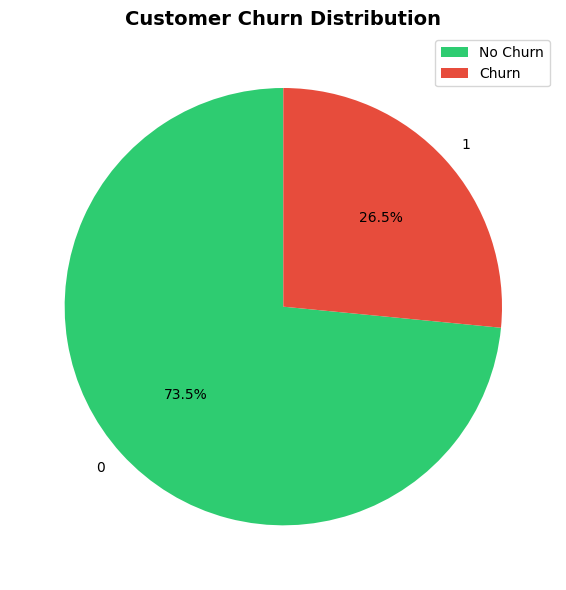

In [5]:
print("1. CHURN DISTRIBUTION : ")
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(f"\nChurn counts:\n{churn_counts}")
print(f"\nChurn percentage:\n{churn_percentage}")

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c']  
churn_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.legend(['No Churn', 'Churn'], loc='upper right')
plt.tight_layout()
plt.savefig('notebooks/eda_plots/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

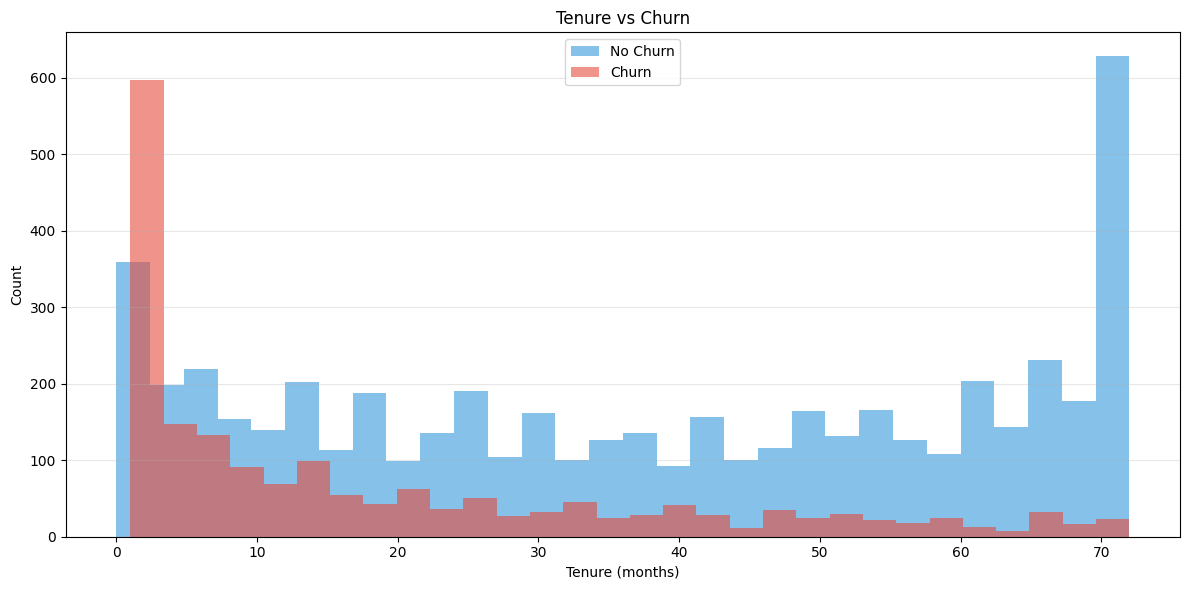

In [6]:
plt.figure(figsize=(12, 6))
plt.hist(df[df['Churn'] == 0]['tenure'], bins=30, alpha=0.6, label='No Churn', color='#3498db')
plt.hist(df[df['Churn'] == 1]['tenure'], bins=30, alpha=0.6, label='Churn', color='#e74c3c')
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/eda_plots/02_tenure_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()


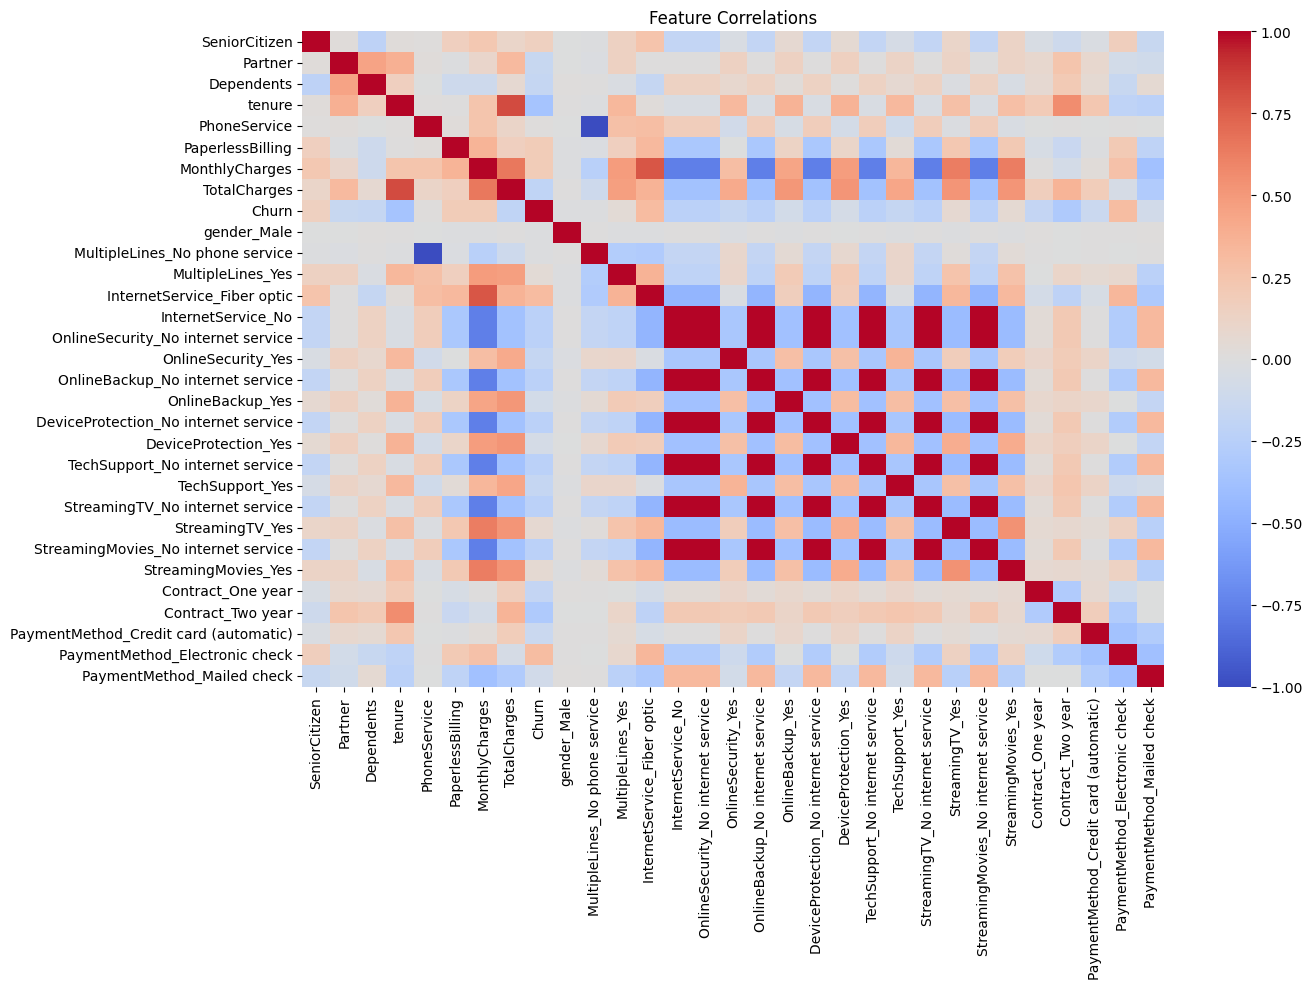

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlations')
plt.tight_layout()
plt.savefig('notebooks/eda_plots/03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()